# Project 4: Spam SMS Classifier

**Objective:** Classify SMS messages as Spam or Ham using Machine Learning  
**Dataset:** SMS Spam Collection (UCI)  
**Algorithms:** Multinomial Naive Bayes, Linear SVM


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("✓ All libraries imported!")


✓ All libraries imported!


In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df = df.drop_duplicates(keep='first')
print(f"Total messages: {len(df)}")
print(df['label'].value_counts())


Total messages: 5169
label
ham     4516
spam     653
Name: count, dtype: int64


In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    text = re.sub(r'\b\d{10}\b|\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' PHONE ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_message'] = df['message'].apply(preprocess_text)
print("✓ Preprocessing complete!")


✓ Preprocessing complete!


In [4]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
X = df['cleaned_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"Training: {X_train_tfidf.shape[0]} samples, {X_train_tfidf.shape[1]} features")


Training: 4135 samples, 5000 features


In [5]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%")

svm_model = LinearSVC(C=1.0, max_iter=1000, random_state=42, dual=False)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")


Naive Bayes Accuracy: 96.52%
Linear SVM Accuracy: 97.97%


In [6]:
print("\n=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

print("\n=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))



=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034


=== SVM Classification Report ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



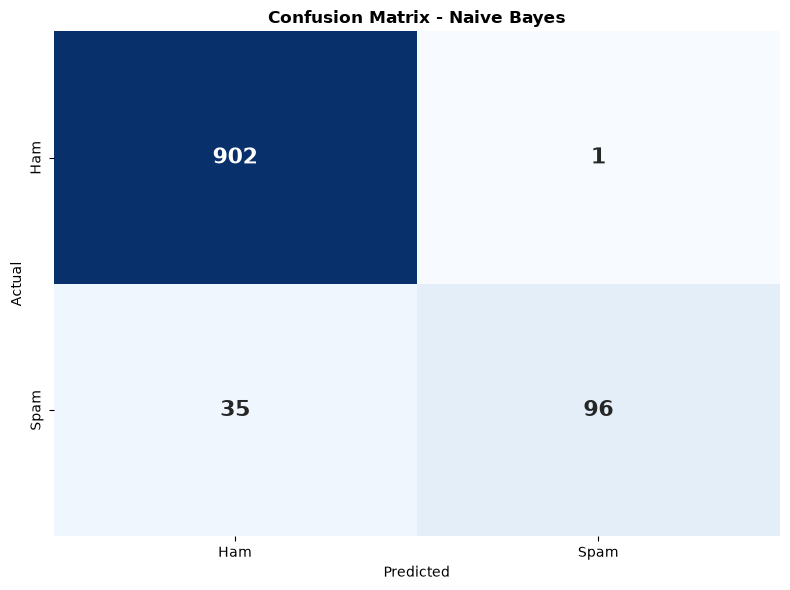

✓ Confusion matrix saved!


In [7]:
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cbar=False, annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - Naive Bayes', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved!")


In [8]:
with open('spam_classifier_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ Model and vectorizer saved!")


✓ Model and vectorizer saved!


In [9]:
def predict_message(message, model, vectorizer):
    cleaned = preprocess_text(message)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    label = "🚨 SPAM" if pred == 1 else "✓ HAM"
    return label

test_msgs = [
    "WIN $1000! Click here now!",
    "Hey, lunch tomorrow?",
    "URGENT: Verify your account immediately!",
    "Thanks for your help!",
    "FREE iPhone! Limited offer!"
]

for msg in test_msgs:
    print(f"{msg[:50]}... → {predict_message(msg, nb_model, tfidf)}")


WIN $1000! Click here now!... → 🚨 SPAM
Hey, lunch tomorrow?... → ✓ HAM
URGENT: Verify your account immediately!... → 🚨 SPAM
Thanks for your help!... → ✓ HAM
FREE iPhone! Limited offer!... → ✓ HAM
